In [5]:
# ! pip install pulp
import pulp

In [6]:
# regions = ["A", "B", "C"]
# w = {
#     "A": 2.0,
#     "B": 1.5,
#     "C": 1.0,
# }
# # Time steps
# T = [0, 1, 2]

# # Separation constraints per time step
# H = {
#     0: [("A", "B")],
#     1: [("A", "B")],
#     2: [("A", "B")]
# }
# V = {
#     0: [("A", "C")],
#     1: [("A", "C")],
#     2: [("A", "C")]
# }

# # Adjacent pairs per time step
# A = {
#     0: [("A", "B"), ("A", "C")],
#     1: [("A", "B"), ("A", "C")],
#     2: [("A", "B"), ("A", "C")]
# }

# # Geographic target positions (optional)
# geo_x = {"A": 0.0, "B": 2.0, "C": 0.0}
# geo_y = {"A": 0.0, "B": 0.0, "C": 2.0}

# # Objective weights
# alpha = 1.0  # TOP objective weight
# beta = 0.5   # Stability objective weight
# gamma = 0.3  # ORG objective weight (optional)

# epsilon = 0.1

# ...existing code...
regions = [
    "Portugal", "Spain", "France", "Belgium", "Netherlands", "Luxembourg",
    "Germany", "Switzerland", "Austria", "Italy", "Slovenia", "Slovakia",
    "Czechia", "Poland", "Denmark", "Norway", "Sweden"
]

gap = 0.1  # Minimum gap between squares (in same units as weights)

# Approximate population (millions) for 2000/2010/2020
pop_millions = {
    2000: {
        "Portugal": 10.3, "Spain": 40.5, "France": 60.7, "Belgium": 10.3,
        "Netherlands": 15.9, "Luxembourg": 0.44, "Germany": 82.2,
        "Switzerland": 7.2, "Austria": 8.1, "Italy": 57.8,
        "Slovenia": 2.0, "Slovakia": 5.4, "Czechia": 10.3,
        "Poland": 38.2, "Denmark": 5.3, "Norway": 4.5, "Sweden": 8.9
    },
    2010: {
        "Portugal": 10.6, "Spain": 46.5, "France": 64.6, "Belgium": 11.0,
        "Netherlands": 16.6, "Luxembourg": 0.51, "Germany": 81.8,
        "Switzerland": 7.8, "Austria": 8.4, "Italy": 60.3,
        "Slovenia": 2.0, "Slovakia": 5.4, "Czechia": 10.5,
        "Poland": 38.2, "Denmark": 5.6, "Norway": 4.9, "Sweden": 9.4
    },
    2020: {
        "Portugal": 10.3, "Spain": 47.3, "France": 67.0, "Belgium": 11.5,
        "Netherlands": 17.4, "Luxembourg": 0.63, "Germany": 83.1,
        "Switzerland": 8.6, "Austria": 8.9, "Italy": 59.6,
        "Slovenia": 2.1, "Slovakia": 5.5, "Czechia": 10.7,
        "Poland": 37.8, "Denmark": 5.8, "Norway": 5.4, "Sweden": 10.3
    }
}

# Time steps
T = [2000, 2010, 2020] #TODO should be something different T = set of adjancent pairs?

# Scale weights from 2020 population to keep square sizes reasonable
scale = 10.0
w = {r: pop_millions[2020][r] / scale for r in regions}
print(f'Weights: {w}')

# Separation constraints per time step (empty for now)
H = {t: [] for t in T}
# for t in H:
#     for r1 in regions:
#         for r2 in regions:
#             if r1 < r2:  # Avoid duplicates and self-pairs
#                 H[t].append((r1, r2))

V = {t: [] for t in T}
# for t in V:
#     for r1 in regions:
#         for r2 in regions:
#             if r1 < r2:  # Avoid duplicates and self-pairs
#                 V[t].append((r1, r2))



# Adjacent pairs per time step (empty for now)
A = {t: [] for t in T} #TODO should be T
for t in A:
    A[t].extend([("Portugal", "Spain"), 
                ("Spain", "France"), 
                ("France", "Belgium"), ("France", "Luxembourg"), ("France", "Germany"), ("France", "Switzerland"), ("France", "Italy"),
                ("Belgium", "Netherlands"), ("Belgium", "Luxembourg"), ("Belgium", "Germany"),
                ("Netherlands", "Germany"),
                ("Luxembourg", "Germany"),
                ("Germany", "Switzerland"), ("Germany", "Austria"), ("Germany", "Czechia"), ("Germany", "Denmark"), ("Germany", "Poland"),
                ("Poland", "Czechia"), ("Slovakia", "Czechia"), ("Poland", "Slovakia"),
                ("Switzerland", "Italy"),
                ("Austria", "Italy"), ("Austria", "Slovenia"), ("Austria", "Slovakia"), ("Austria", "Czechia"),
                ("Italy", "Slovenia"),
                ("Norway", "Sweden")])


# Geographic target positions (approx. capital coordinates)
geo_x = {
    "Portugal": -9.14, "Spain": -3.70, "France": 2.35, "Belgium": 4.35,
    "Netherlands": 4.90, "Luxembourg": 6.13, "Germany": 13.40,
    "Switzerland": 7.45, "Austria": 16.37, "Italy": 12.50,
    "Slovenia": 14.50, "Slovakia": 17.10, "Czechia": 14.42,
    "Poland": 21.00, "Denmark": 12.57, "Norway": 10.75, "Sweden": 18.07
}
geo_y = {
    "Portugal": 38.72, "Spain": 40.42, "France": 48.86, "Belgium": 50.85,
    "Netherlands": 52.37, "Luxembourg": 49.61, "Germany": 52.52,
    "Switzerland": 46.95, "Austria": 48.21, "Italy": 41.90,
    "Slovenia": 46.06, "Slovakia": 48.15, "Czechia": 50.08,
    "Poland": 52.23, "Denmark": 55.68, "Norway": 59.91, "Sweden": 59.33
}

for r1 in regions:
    for r2 in regions:
        if r1 < r2:
            # dx = abs(geo_x[r1] - geo_x[r2])
            # dy = abs(geo_y[r1] - geo_y[r2])
            dx = geo_x[r1] - geo_x[r2]  # signed difference
            dy = geo_y[r1] - geo_y[r2]  # signed difference
            
            # Only force separation if far apart AND not adjacent
            is_adjacent = (r1, r2) in [(a, b) for t in T for (a, b) in A[t]] or \
                          (r2, r1) in [(a, b) for t in T for (a, b) in A[t]]
            
            if not is_adjacent:
                # Force geographic ordering only for non-neighbors
                if abs(dx) > abs(dy):  # More horizontal separation
                    if dx > 0:  # r1 is west of r2
                        for t in H:
                            H[t].append((r1, r2))
                    else:  # r2 is west of r1
                        for t in H:
                            H[t].append((r2, r1))
                else:  # More vertical separation
                    if dy > 0:  # r1 is south of r2
                        for t in V:
                            V[t].append((r1, r2))
                    else:  # r2 is south of r1
                        for t in V:
                            V[t].append((r2, r1))
                # if dx > dy:  # More horizontal spread
                #     for t in H:
                #         H[t].append((r1, r2))
                # elif dy > dx:  # More vertical spread
                #     for t in V:
                #         V[t].append((r1, r2))


# Objective weights
alpha = 5.0  # TOP objective weight
beta = 0.5   # Stability objective weight
gamma = 2.0  # ORG objective weight (optional)

epsilon = 0.1
delta = 0.25

c = 0.1
print(f"H pairs: {len(H[T[0]])}")
print(f"V pairs: {len(V[T[0]])}")
print(f"A pairs: {len(A[T[0]])}")


Weights: {'Portugal': 1.03, 'Spain': 4.7299999999999995, 'France': 6.7, 'Belgium': 1.15, 'Netherlands': 1.7399999999999998, 'Luxembourg': 0.063, 'Germany': 8.309999999999999, 'Switzerland': 0.86, 'Austria': 0.89, 'Italy': 5.96, 'Slovenia': 0.21000000000000002, 'Slovakia': 0.55, 'Czechia': 1.0699999999999998, 'Poland': 3.78, 'Denmark': 0.58, 'Norway': 0.54, 'Sweden': 1.03}
H pairs: 64
V pairs: 45
A pairs: 27


In [7]:
def get_gap(region1, region2, A=A):
    if (region1, region2) in A:
        return 0.0
    else:
        return epsilon

def get_c(region1, region2, c=c):
    if (region1, region2) in A:
        return c
    else:
        return c * 0.1

In [ ]:
# Create LP
model = pulp.LpProblem("DemersCartogram", pulp.LpMinimize)

# Variables: centers of squares at each time step
x = {(r, t): pulp.LpVariable(f"x_{r}_{t}") for r in regions for t in T}
y = {(r, t): pulp.LpVariable(f"y_{r}_{t}") for r in regions for t in T}

# Auxiliary distance variables (non-negative)
h = {(r, r2, t): pulp.LpVariable(f"h_{r}_{r2}_{t}", lowBound=0) 
     for r in regions for r2 in regions if r != r2 for t in T}
v = {(r, r2, t): pulp.LpVariable(f"v_{r}_{r2}_{t}", lowBound=0) 
     for r in regions for r2 in regions if r != r2 for t in T}

# Movement variables (non-negative)
delta_x = {(r, t): pulp.LpVariable(f"delta_x_{r}_{t}", lowBound=0) 
           for r in regions for t in T if t > 0}
delta_y = {(r, t): pulp.LpVariable(f"delta_y_{r}_{t}", lowBound=0) 
           for r in regions for t in T if t > 0}

# Geographic deviation variables (optional, non-negative)
dx_geo = {(r, t): pulp.LpVariable(f"dx_geo_{r}_{t}", lowBound=0) 
          for r in regions for t in T}
dy_geo = {(r, t): pulp.LpVariable(f"dy_geo_{r}_{t}", lowBound=0) 
          for r in regions for t in T}

# --- Constraint (2): Horizontal non-overlap ---
for t in T:
    for r, r2 in H[t]:
        model += (
            x[r2, t] - x[r, t] >= ((w[r] + w[r2]) / 2) + gap,
            f"H_sep_{r}_{r2}_t{t}"
        )

# --- Constraint (3): Vertical non-overlap ---
for t in T:
    for r, r2 in V[t]:
        model += (
            y[r2, t] - y[r, t] >= ((w[r] + w[r2]) / 2) + gap,
            f"V_sep_{r}_{r2}_t{t}"
        )

# --- Constraint (4): Linearization of horizontal distances ---
for t in T:
    for r in regions:
        for r2 in regions:
            if r != r2:
                model += (
                    h[r, r2, t] >= 0, # x[r, t] - x[r2, t],
                    f"h_lin1_{r}_{r2}_t{t}"
                )
                model += (
                    v[r, r2, t] >= 0, # x[r2, t] - x[r, t],
                    f"v_lin2_{r}_{r2}_t{t}"
                )

# --- Constraint (8):  ---
for t in T:
    for r in regions:
        for r2 in regions:
            if r != r2:
                model += h[r, r2, t] >= (x[r, t] - x[r2, t]) - w[r] + delta
                model += h[r, r2, t] >= (x[r2, t] - x[r, t]) - w[r] + delta
                model += v[r, r2, t] >= (y[r, t] - y[r2, t]) - w[r] + delta
                model += v[r, r2, t] >= (y[r2, t] - y[r, t]) - w[r] + delta

# --- Adjacency position constraints with linearized abs ---
for t in T:
    for r in regions:
        for r2 in regions:
            if r != r2:
                # Linearize abs((y[r, t] + alpha*(x[r2, t] - x[r, t])) - y[r2, t])
                d1 = pulp.LpVariable(f"d1_{r}_{r2}_{t}", lowBound=0)
                expr1 = (y[r, t] + alpha * (x[r2, t] - x[r, t])) - y[r2, t]
                model += d1 >= expr1, f"adj_pos_{r}_{r2}_t{t}"
                model += d1 >= -expr1, f"adj_pos_rev_{r}_{r2}_t{t}"

                # Linearize abs((x[r, t] + (1/alpha)*(y[r2, t] - y[r, t])) - x[r2, t])
                d2 = pulp.LpVariable(f"d2_{r}_{r2}_{t}", lowBound=0)
                expr2 = (x[r, t] + (1/alpha) * (y[r2, t] - y[r, t])) - x[r2, t]
                model += d2 >= expr2, f"adj_pos_x_{r}_{r2}_t{t}"
                model += d2 >= -expr2, f"adj_pos_x_rev_{r}_{r2}_t{t}"

# --- Objective (12): Stability - minimize movement ---
stability_objective = pulp.lpSum(
    delta_x[r, t] + delta_y[r, t]
    for t in T if t > 0 for r in regions
)

# --- Optional: ORG - geographic positioning ---
org_objective = pulp.lpSum(
    dx_geo[r, t] + dy_geo[r, t]
    for t in T for r in regions
)

# Fix initial position
model += x["Portugal", 2000] == 0
model += y["Portugal", 2000] == 0

# --- Objective (13): Combined objective ---
model += alpha + beta * stability_objective + gamma * org_objective

# Solve
model.solve(pulp.PULP_CBC_CMD(msg=False))

# Results
for t in T:
    print(f"\n=== Time step {t} ===")
    for r in regions:
        print(f"{r}: x={x[r,t].value():.2f}, y={y[r,t].value():.2f}")


=== Time step 2000 ===
Portugal: x=0.00, y=0.00
Spain: x=1.85, y=3.04
France: x=-3.96, y=3.32
Belgium: x=-1.19, y=0.00
Netherlands: x=-1.49, y=-1.00
Luxembourg: x=-0.65, y=0.00
Germany: x=-4.77, y=4.77
Switzerland: x=-1.04, y=1.10
Austria: x=-7.86, y=1.06
Italy: x=-3.60, y=12.65
Slovenia: x=-7.52, y=9.13
Slovakia: x=-8.00, y=9.30
Czechia: x=-7.95, y=1.15
Poland: x=-10.29, y=2.50
Denmark: x=-7.71, y=0.23
Norway: x=0.00, y=-2.24
Sweden: x=-8.61, y=0.00

=== Time step 2010 ===
Portugal: x=7.95, y=0.00
Spain: x=6.62, y=3.04
France: x=3.98, y=3.32
Belgium: x=1.21, y=0.00
Netherlands: x=1.50, y=-1.00
Luxembourg: x=0.67, y=0.00
Germany: x=0.00, y=4.77
Switzerland: x=1.06, y=1.10
Austria: x=0.00, y=1.06
Italy: x=0.00, y=12.65
Slovenia: x=0.00, y=9.13
Slovakia: x=-0.48, y=9.30
Czechia: x=0.00, y=1.15
Poland: x=-2.44, y=2.50
Denmark: x=0.00, y=0.23
Norway: x=0.00, y=-2.24
Sweden: x=-0.91, y=0.00

=== Time step 2020 ===
Portugal: x=7.95, y=0.00
Spain: x=6.62, y=3.04
France: x=3.98, y=3.32
Belgiu

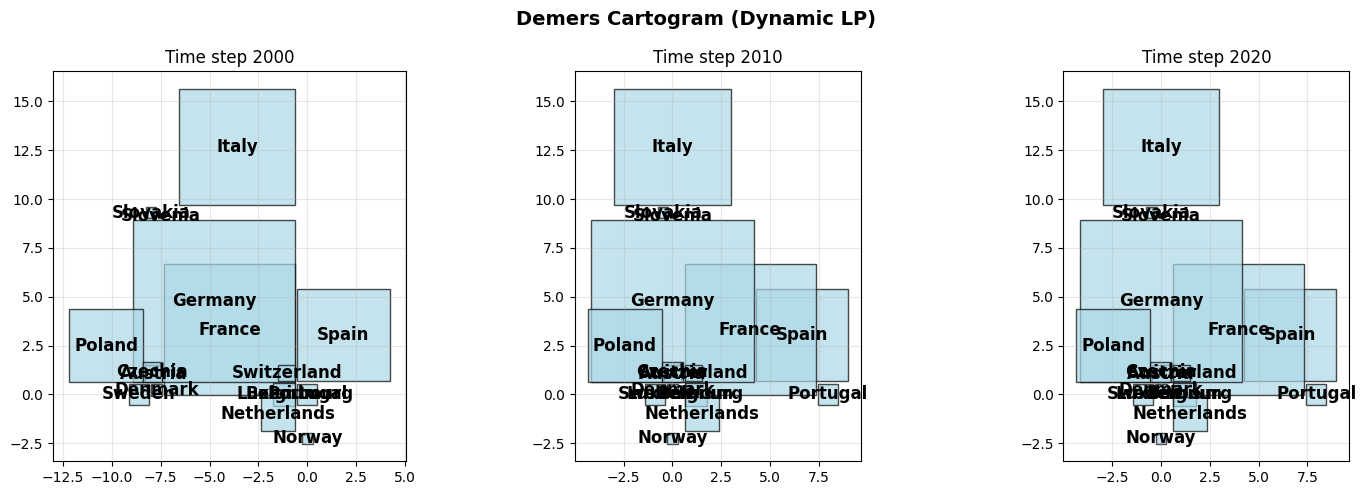

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, axes = plt.subplots(1, len(T), figsize=(5*len(T), 5))

if len(T) == 1:
    axes = [axes]

for idx, t in enumerate(T):
    ax = axes[idx]
    
    for r in regions:
        xr = x[r, t].value()
        yr = y[r, t].value()

        xr = 0.0 if xr is None else xr
        yr = 0.0 if yr is None else yr

        size = w[r]

        square = patches.Rectangle(
            (xr - size/2, yr - size/2),
            size,
            size,
            edgecolor="black",
            facecolor="lightblue",
            alpha=0.7
        )

        ax.add_patch(square)
        ax.text(xr, yr, r, ha="center", va="center", fontsize=12, fontweight="bold")

    ax.set_aspect("equal")
    ax.autoscale()
    ax.set_title(f"Time step {t}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Demers Cartogram (Dynamic LP)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
# ! pip install pulp
import pulp

In [11]:
regions = ["A", "B", "C"]
w = {
    "A": 2.0,
    "B": 1.5,
    "C": 1.0,
}
H = [("A", "B")]   # A is left of B
V = [("A", "C")]   # A is below C
epsilon = 0.1

def gap(r, r_prime, adjacent):
    return 0.0 if adjacent else epsilon


In [12]:
# Create LP
model = pulp.LpProblem("DemersCartogram", pulp.LpMinimize)

# Variables: centers of squares
x = {r: pulp.LpVariable(f"x_{r}") for r in regions}
y = {r: pulp.LpVariable(f"y_{r}") for r in regions}

# Helper: half-sum of side lengths
def w_rr(r, r2):
    return 0.5 * (w[r] + w[r2])

# --- Second constraint set (Section 3, eq. 2 & 3) ---

# Horizontal separation
for r, r2 in H:
    model += (
        x[r2] - x[r] >= w_rr(r, r2) + epsilon,
        f"H_sep_{r}_{r2}"
    )

# Vertical separation
for r, r2 in V:
    model += (
        y[r2] - y[r] >= w_rr(r, r2) + epsilon,
        f"V_sep_{r}_{r2}"
    )

# Dummy objective (LP requires one)
model += 0

model += x["A"] == 0
model += y["A"] == 0


# Solve
model.solve(pulp.PULP_CBC_CMD(msg=False))

# Results
for r in regions:
    print(r, x[r].value(), y[r].value())


A 0.0 0.0
B 1.85 None
C None 1.6


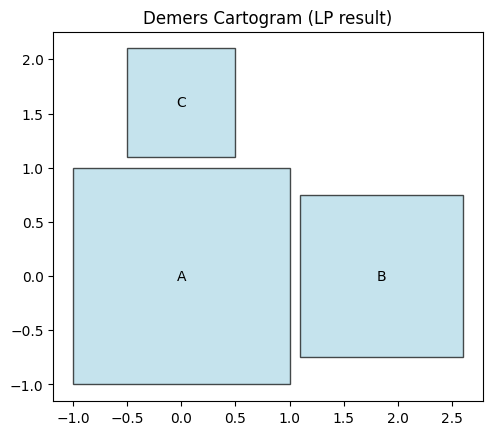

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots()

for r in regions:
    xr = x[r].value()
    yr = y[r].value()

    xr = 0.0 if xr is None else xr
    yr = 0.0 if yr is None else yr

    size = w[r]

    square = patches.Rectangle(
        (xr - size/2, yr - size/2),
        size,
        size,
        edgecolor="black",
        facecolor="lightblue",
        alpha=0.7
    )

    ax.add_patch(square)
    ax.text(xr, yr, r, ha="center", va="center")

ax.set_aspect("equal")
ax.autoscale()
ax.set_title("Demers Cartogram (LP result)")
plt.show()
